In [1]:
import matplotlib.pyplot as plt
from mpl_toolkits.basemap import Basemap
import numpy as np
from eofs.standard import Eof
def plot_map_metric(lon,lat,data,file_name):
#     m = Basemap(projection='cyl', resolution='l',
#             llcrnrlat=np.min(lat), urcrnrlat=np.max(lat),
#             llcrnrlon=np.min(lon), urcrnrlon=np.max(lon), )

    m = Basemap(projection='cyl', resolution='l',
            llcrnrlat=np.min(lat_sst), urcrnrlat=np.max(lat_sst),
            llcrnrlon=np.min(lon_sst), urcrnrlon=np.max(lon_sst), )
    #m.drawcoastlines()
    #plt.show()
    lons,lats= np.meshgrid(lon,lat)
    x,y = m(lons,lats)
    
    #m.drawcoastlines()
    levels = np.linspace(min(np.unique(data)),max(np.unique(data)),21)
    #levels = np.linspace(0.0,1.0,21)
    #levels=[-30,-20,-12,-9,-6,-2,-1,+1,+2,+6,+9,+12,+20,+30]
    sst = m.contourf(x,y,data,levels=levels,cmap='Spectral')
    cb = m.colorbar(sst,"bottom", size="15%", pad="10%")
    m.drawcoastlines()
    m.drawparallels(np.arange(-90., 91., 30.), labels=[1, 0, 0, 0])
    m.drawmeridians(np.arange(0., 361., 45.), labels=[0, 0, 0, 1])
    #plt.title('sst')
    #cb.set_label('sst')

    plt.savefig(file_name)
    


    plt.show()
    plt.clf()



def EOF(Data, lat, lon):
    wgts   = np.cos(np.deg2rad(lat))
    wgts   = wgts.reshape(len(wgts), 1)
    #solver1 = Eof(np.array(ser_original[6]), weights=wgts)

    coslat = np.cos(np.deg2rad(lat))
    wgts = np.sqrt(coslat)[..., np.newaxis]
    solver =Eof(Data,weights=wgts)
    eof1=solver.eofs()

    pc=solver.pcs(pcscaling=1)
    varfrac=solver.varianceFraction()
    lambdas=solver.eigenvalues()


    parallels = np.arange(-90,90,20)
    meridians = np.arange(-180,180,40)

    fig=plt.figure(figsize=(10,16)) 

    m=Basemap(projection='cyl', llcrnrlon=min(lon), llcrnrlat=min(lat),
            urcrnrlon=max(lon), urcrnrlat=max(lat), resolution='l')
    x, y = m(*np.meshgrid(lon,lat))
    clevs = np.linspace(-0.1,0.1,11)

    cs = m.contourf(x,y,eof1[0,:,:].squeeze(),clevs,cmap=plt.cm.RdBu_r)
    m.drawcoastlines()
    m.fillcontinents(color='#000000',lake_color='#99ffff')
    m.drawparallels(parallels,labels=[1,0,0,0])
    m.drawmeridians(meridians,labels=[1,0,0,1])

    cb=m.colorbar(cs, 'bottom', size='5%',pad='10%')
    #cb.set_label('EOF', fontsize=10)
    plt.title('EOF1', fontsize=15)  
    plt.show()
    


In [2]:
import xarray as xr
ds = xr.open_dataset('../data/external/COBE_SST.nc')
#ds.squeeze()
ds

<xarray.Dataset> Size: 544MB
Dimensions:  (lat: 180, lon: 360, time: 2100)
Coordinates:
  * lat      (lat) float32 720B 89.5 88.5 87.5 86.5 ... -86.5 -87.5 -88.5 -89.5
  * lon      (lon) float32 1kB 0.5 1.5 2.5 3.5 4.5 ... 356.5 357.5 358.5 359.5
  * time     (time) datetime64[ns] 17kB 1850-01-01 1850-02-01 ... 2024-12-01
Data variables:
    sst      (time, lat, lon) float32 544MB ...
Attributes:
    title:            created 12/2013 from data provided by JRA
    history:          Created 12/2012 from data obtained from JRA by ESRL/PSD
    platform:         Analyses
    citation:         Hirahara, S., Ishii, M., and Y. Fukuda,2014: Centennial...
    institution:      NOAA ESRL/PSD
    Conventions:      CF-1.2
    dataset_title:    COBE-SST2 Sea Surface Temperature and Ice
    original_source:  https://climate.mri-jma.go.jp/pub/ocean/cobe-sst2/
    References:       http://www.psl.noaa.gov/data/gridded/cobe2.html

In [3]:
ds = ds.sel(time=(ds.time.dt.year.isin(range(1870,2016))))

In [4]:
ds=ds.fillna(0)

In [6]:
360-168

192

In [16]:
P1_lat = ds.lat.values[(ds.lat.values>-53)&(ds.lat.values<-40)]
P1_lon = ds.lon.values[(ds.lon.values>172)&(ds.lon.values<192)]
gb = ds.squeeze().sel(lat=P1_lat,lon=P1_lon).groupby('time.month')
clim=gb.mean('time')
anom = gb - clim
P1 = anom.fillna(0)
P1

<xarray.Dataset> Size: 2MB
Dimensions:  (time: 1752, lat: 13, lon: 20)
Coordinates:
  * lat      (lat) float32 52B -40.5 -41.5 -42.5 -43.5 ... -50.5 -51.5 -52.5
  * lon      (lon) float32 80B 172.5 173.5 174.5 175.5 ... 189.5 190.5 191.5
  * time     (time) datetime64[ns] 14kB 1870-01-01 1870-02-01 ... 2015-12-01
    month    (time) int64 14kB 1 2 3 4 5 6 7 8 9 10 ... 3 4 5 6 7 8 9 10 11 12
Data variables:
    sst      (time, lat, lon) float32 2MB 0.5476 0.5138 ... -0.08142 -0.09197

In [15]:
P2_lat = ds.lat.values[(ds.lat.values>-23)&(ds.lat.values<-10)]
P2_lon = ds.lon.values[(ds.lon.values>105)&(ds.lon.values<120)]
gb = ds.squeeze().sel(lat=P2_lat,lon=P2_lon).groupby('time.month')
clim=gb.mean('time')
anom = gb - clim
P2 = anom.fillna(0)
P2

<xarray.Dataset> Size: 1MB
Dimensions:  (time: 1752, lat: 13, lon: 15)
Coordinates:
  * lat      (lat) float32 52B -10.5 -11.5 -12.5 -13.5 ... -20.5 -21.5 -22.5
  * lon      (lon) float32 60B 105.5 106.5 107.5 108.5 ... 117.5 118.5 119.5
  * time     (time) datetime64[ns] 14kB 1870-01-01 1870-02-01 ... 2015-12-01
    month    (time) int64 14kB 1 2 3 4 5 6 7 8 9 10 ... 3 4 5 6 7 8 9 10 11 12
Data variables:
    sst      (time, lat, lon) float32 1MB -0.3644 -0.3729 -0.3786 ... 0.0 0.0

In [17]:
P3_lat = ds.lat.values[(ds.lat.values>-55)&(ds.lat.values<-45)]
P3_lon = ds.lon.values[(ds.lon.values>100)&(ds.lon.values<115)]
gb = ds.squeeze().sel(lat=P3_lat,lon=P3_lon).groupby('time.month')
clim=gb.mean('time')
anom = gb - clim
P3 = anom.fillna(0)
P3

<xarray.Dataset> Size: 1MB
Dimensions:  (time: 1752, lat: 10, lon: 15)
Coordinates:
  * lat      (lat) float32 40B -45.5 -46.5 -47.5 -48.5 ... -52.5 -53.5 -54.5
  * lon      (lon) float32 60B 100.5 101.5 102.5 103.5 ... 112.5 113.5 114.5
  * time     (time) datetime64[ns] 14kB 1870-01-01 1870-02-01 ... 2015-12-01
    month    (time) int64 14kB 1 2 3 4 5 6 7 8 9 10 ... 3 4 5 6 7 8 9 10 11 12
Data variables:
    sst      (time, lat, lon) float32 1MB -0.2627 -0.2534 ... 0.2279 0.2208

In [18]:
P4_lat = ds.lat.values[(ds.lat.values>-48)&(ds.lat.values<-32)]
P4_lon = ds.lon.values[(ds.lon.values>40)&(ds.lon.values<70)]
gb = ds.squeeze().sel(lat=P4_lat,lon=P4_lon).groupby('time.month')
clim=gb.mean('time')
anom = gb - clim
P4 = anom.fillna(0)
P4

<xarray.Dataset> Size: 3MB
Dimensions:  (time: 1752, lat: 16, lon: 30)
Coordinates:
  * lat      (lat) float32 64B -32.5 -33.5 -34.5 -35.5 ... -45.5 -46.5 -47.5
  * lon      (lon) float32 120B 40.5 41.5 42.5 43.5 44.5 ... 66.5 67.5 68.5 69.5
  * time     (time) datetime64[ns] 14kB 1870-01-01 1870-02-01 ... 2015-12-01
    month    (time) int64 14kB 1 2 3 4 5 6 7 8 9 10 ... 3 4 5 6 7 8 9 10 11 12
Data variables:
    sst      (time, lat, lon) float32 3MB 0.2326 0.2739 0.2925 ... 0.4184 0.3801

In [19]:
P5_lat = ds.lat.values[(ds.lat.values>0)&(ds.lat.values<15)]
P5_lon = ds.lon.values[(ds.lon.values>52)&(ds.lon.values<62)]
gb = ds.squeeze().sel(lat=P5_lat,lon=P5_lon).groupby('time.month')
clim=gb.mean('time')
anom = gb - clim
P5 = anom.fillna(0)
P5

<xarray.Dataset> Size: 1MB
Dimensions:  (time: 1752, lat: 15, lon: 10)
Coordinates:
  * lat      (lat) float32 60B 14.5 13.5 12.5 11.5 10.5 ... 4.5 3.5 2.5 1.5 0.5
  * lon      (lon) float32 40B 52.5 53.5 54.5 55.5 56.5 57.5 58.5 59.5 60.5 61.5
  * time     (time) datetime64[ns] 14kB 1870-01-01 1870-02-01 ... 2015-12-01
    month    (time) int64 14kB 1 2 3 4 5 6 7 8 9 10 ... 3 4 5 6 7 8 9 10 11 12
Data variables:
    sst      (time, lat, lon) float32 1MB -0.2154 -0.2343 -0.2513 ... 1.196 1.2

In [20]:
P6_lat = ds.lat.values[(ds.lat.values>-5)&(ds.lat.values<5)]
P6_lon = ds.lon.values[(ds.lon.values>190)&(ds.lon.values<230)]
gb = ds.squeeze().sel(lat=P6_lat,lon=P6_lon).groupby('time.month')
clim=gb.mean('time')
anom = gb - clim
P6 = anom.fillna(0)
P6

<xarray.Dataset> Size: 3MB
Dimensions:  (time: 1752, lat: 10, lon: 40)
Coordinates:
  * lat      (lat) float32 40B 4.5 3.5 2.5 1.5 0.5 -0.5 -1.5 -2.5 -3.5 -4.5
  * lon      (lon) float32 160B 190.5 191.5 192.5 193.5 ... 227.5 228.5 229.5
  * time     (time) datetime64[ns] 14kB 1870-01-01 1870-02-01 ... 2015-12-01
    month    (time) int64 14kB 1 2 3 4 5 6 7 8 9 10 ... 3 4 5 6 7 8 9 10 11 12
Data variables:
    sst      (time, lat, lon) float32 3MB -0.3346 -0.3717 -0.41 ... 2.579 2.608

In [23]:
P7_lat = ds.lat.values[(ds.lat.values>-25)&(ds.lat.values<-10)]
P7_lon = ds.lon.values[(ds.lon.values>232)&(ds.lon.values<262)]
gb = ds.squeeze().sel(lat=P7_lat,lon=P7_lon).groupby('time.month')
clim=gb.mean('time')
anom = gb - clim
P7 = anom.fillna(0)
P7

<xarray.Dataset> Size: 3MB
Dimensions:  (time: 1752, lat: 15, lon: 30)
Coordinates:
  * lat      (lat) float32 60B -10.5 -11.5 -12.5 -13.5 ... -22.5 -23.5 -24.5
  * lon      (lon) float32 120B 232.5 233.5 234.5 235.5 ... 259.5 260.5 261.5
  * time     (time) datetime64[ns] 14kB 1870-01-01 1870-02-01 ... 2015-12-01
    month    (time) int64 14kB 1 2 3 4 5 6 7 8 9 10 ... 3 4 5 6 7 8 9 10 11 12
Data variables:
    sst      (time, lat, lon) float32 3MB -0.5536 -0.534 ... -0.07005 -0.02682

In [25]:
P8_lat = ds.lat.values[(ds.lat.values>42)&(ds.lat.values<52)]
P8_lon = ds.lon.values[(ds.lon.values>158)&(ds.lon.values<188)]
gb = ds.squeeze().sel(lat=P8_lat,lon=P8_lon).groupby('time.month')
clim=gb.mean('time')
anom = gb - clim
P8 = anom.fillna(0)
P8

<xarray.Dataset> Size: 2MB
Dimensions:  (time: 1752, lat: 10, lon: 30)
Coordinates:
  * lat      (lat) float32 40B 51.5 50.5 49.5 48.5 47.5 46.5 45.5 44.5 43.5 42.5
  * lon      (lon) float32 120B 158.5 159.5 160.5 161.5 ... 185.5 186.5 187.5
  * time     (time) datetime64[ns] 14kB 1870-01-01 1870-02-01 ... 2015-12-01
    month    (time) int64 14kB 1 2 3 4 5 6 7 8 9 10 ... 3 4 5 6 7 8 9 10 11 12
Data variables:
    sst      (time, lat, lon) float32 2MB -0.02281 -0.01162 ... 0.3184 0.3389

In [26]:
P1_Index=P1.mean(dim=['lat','lon'])
P2_Index=P2.mean(dim=['lat','lon'])
P3_Index=P3.mean(dim=['lat','lon'])
P4_Index=P4.mean(dim=['lat','lon']) 
P5_Index=P5.mean(dim=['lat','lon'])
P6_Index=P6.mean(dim=['lat','lon'])
P7_Index=P7.mean(dim=['lat','lon'])
P8_Index=P8.mean(dim=['lat','lon'])
    

In [35]:
import pandas as pd
data = {
    'P1': P1_Index.sst.values,
    'P2': P2_Index.sst.values,
    'P3': P3_Index.sst.values,
    'P4': P4_Index.sst.values,
    'P5': P5_Index.sst.values,
    'P6': P6_Index.sst.values,
    'P7': P7_Index.sst.values,
    'P8': P8_Index.sst.values
    
}

df = pd.DataFrame(data)
df.to_csv('../data/external/P1_8.csv', index=False)

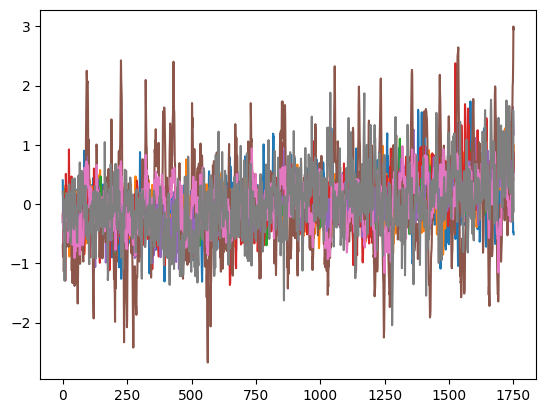

In [29]:
import matplotlib.pyplot as plt
plt.plot(P1_Index.sst.values)
plt.plot(P2_Index.sst.values)
plt.plot(P3_Index.sst.values)
plt.plot(P4_Index.sst.values)
plt.plot(P5_Index.sst.values)
plt.plot(P6_Index.sst.values)
plt.plot(P7_Index.sst.values)
plt.plot(P8_Index.sst.values)
plt.show()